In [11]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.font_manager
import numpy as np
import random
import matplotlib.pyplot as plt

font_pathes = [
    "/System/Library/Fonts/Supplemental/Arial.ttf",
    "/System/Library/Fonts/Supplemental/Times New Roman.ttf",
    "/System/Library/Fonts/Supplemental/Brush Script.ttf",
    "/System/Library/Fonts/Supplemental/GillSans.ttf",
    "/System/Library/Fonts/Supplemental/Trattatello.ttf",
    "/Users/yuonoda/Library/Fonts/NotoSans-BoldItalic.ttf",
    "/Users/yuonoda/Library/Fonts/NotoSans-Bold.ttf",
    "/Users/yuonoda/Library/Fonts/NotoSans-Italic.ttf",
    "/System/Library/Fonts/MarkerFelt.ttc",
    "/System/Library/Fonts/Supplemental/Trattatello.ttf",
]
# font_paths = matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf')
print("variation patterns=", len(font_pathes))

# 利用するフォントサイズをパターン指定
font_sizes = range(20, 100, 1)
print("sizes patterns =", len(font_sizes))

# 生成した画像とラベルを格納するリスト
images = []
labels = []

# 各フォントに対して
for font_path in font_pathes:
    
    # 各フォントサイズに対して
    for font_size in font_sizes:
        try:
            # フォントオブジェクトを作成
            font = ImageFont.truetype(font_path, size=font_size)
        except IOError:
            continue  # エラーが起きた場合、このフォントはスキップします

        # 数字0-9を描画
        for number in range(10):
            # 0の場合、白い画像を生成
            if number == 0:
                np_image = np.ones((100, 100), dtype=np.uint8)
                
                # 画像とラベルを保存
                images.append(np_image)
                labels.append(number)
                continue
            
            # 1-9のときは、3回ずつノイズを加えてデータを増やす
            for _ in range(3):    
                # 新しい画像オブジェクトを生成 (28x28, 白背景)
                image = Image.new('L', (100, 100), 255)
                draw = ImageDraw.Draw(image)
    
                # 位置ノイズを作成
                x_noise = random.randint(-20, 20)
                y_noise = random.randint(-20, 20)
                
                # 数字を中央に描画
                text = str(number)
                text_width, text_height = draw.textsize(text, font=font)
                x = (image.width - text_width) // 2 + x_noise
                y = (image.height - text_height) // 2 + y_noise
                draw.text((x, y), text, font=font, fill=0)
                
                # NumPy配列に変換して二値化
                np_image = np.array(image)
                np_image = (np_image < 128).astype(np.uint8)  # 128を閾値として二値化
    
                # 画像とラベルを保存
                images.append(np_image)
                labels.append(number)
            
print("total images =", len(images))


variation patterns= 10
sizes patterns = 80


/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_3071/1419369302.py:64: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_3071/1419369302.py:64: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_3071/1419369302.py:64: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_3071/1419369302.py:64: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength 

total images = 20160


/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_3071/1419369302.py:64: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_3071/1419369302.py:64: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_3071/1419369302.py:64: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_3071/1419369302.py:64: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength 

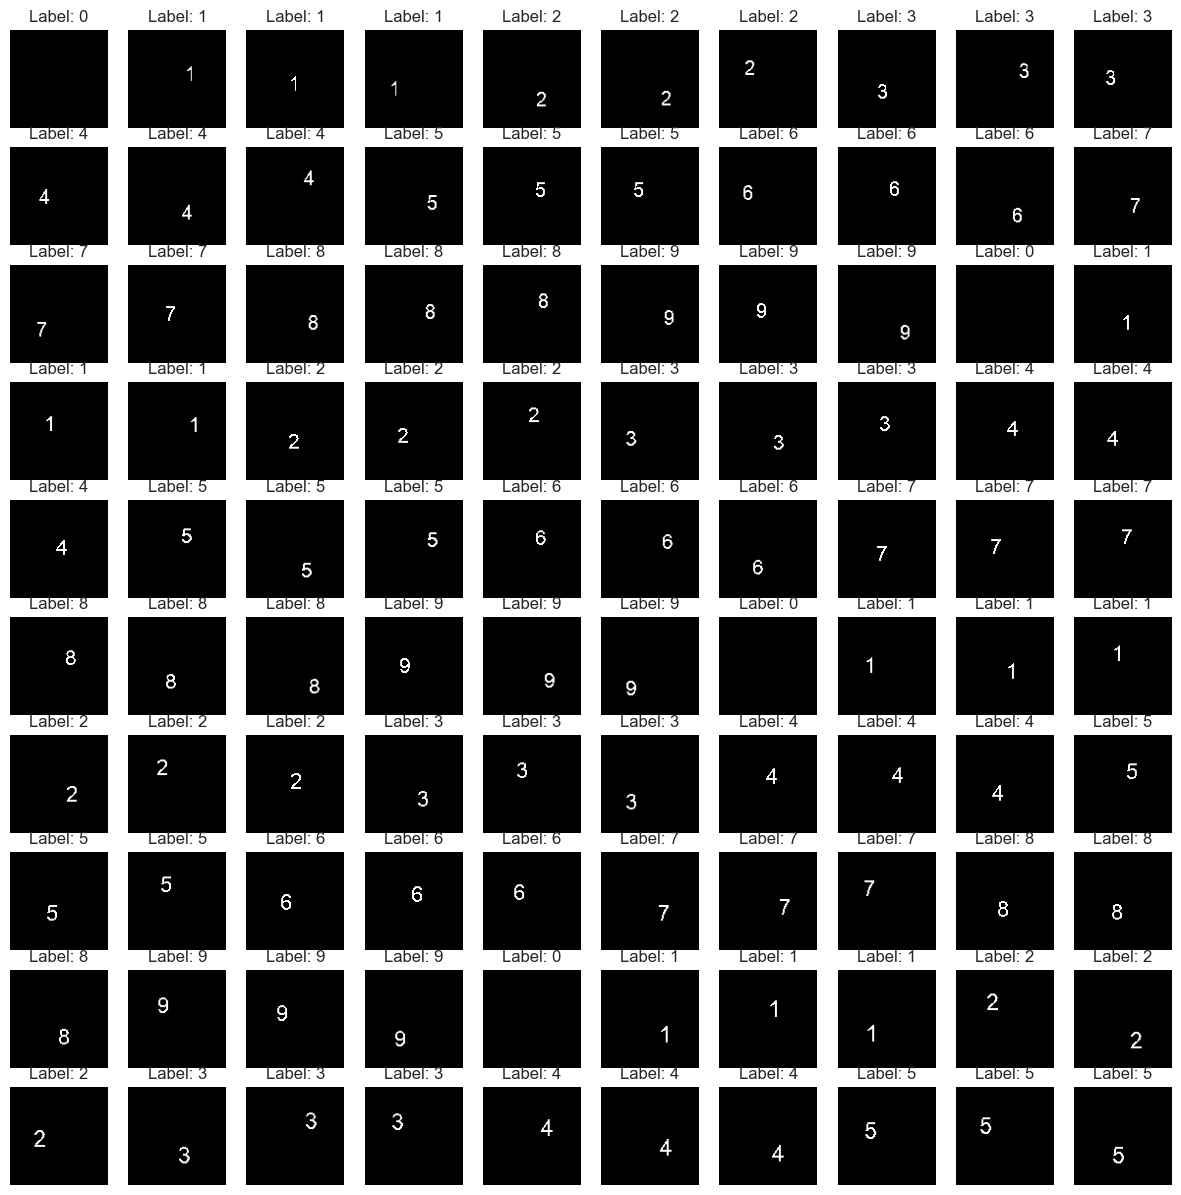

In [12]:
import matplotlib.pyplot as plt
import math

# イメージの合計枚数を取得
images_to_show =random.sample(images, 100) # ランダムに100個取得
# images_to_show = images
total_images = len(images_to_show)

# グリッドのサイズを計算 (例: 20x10)
cols = 10  # 1行に10画像表示
rows = math.ceil(total_images / cols)  # 必要な行数を計算

# 画像とラベルを表示
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
for idx, ax in enumerate(axes.flatten()):
    if idx < total_images:
        ax.imshow(images[idx], cmap='gray')
        ax.set_title(f"Label: {labels[idx]}")
    ax.axis('off')  # 軸を非表示に
plt.show()


In [13]:
# リサイズして保存
resized_images = []
for image in images:
    img = Image.fromarray(image)
    resized_img = img.resize((28, 28), Image.ANTIALIAS)
    resized_images.append(np.array(resized_img))

# numpy配列に変換
resized_images = np.array(resized_images)
labels = np.array(labels)

# .npz形式で保存
x_reshaped = resized_images.reshape((resized_images.shape[0], -1))
np.savez("../images_and_labels.npz", x=x_reshaped, y=labels)


/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_3071/1629271222.py:5: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  resized_img = img.resize((28, 28), Image.ANTIALIAS)


## 画像マスの抽出

In [260]:
import cv2
filepath = "../data/level1/sudoku_026"
imgname = filepath + ".jpg"
img = cv2.imread(imgname, cv2.IMREAD_COLOR)
if img is None:
    raise IOError("FaileRd to load image: {:s}".format(filepath))

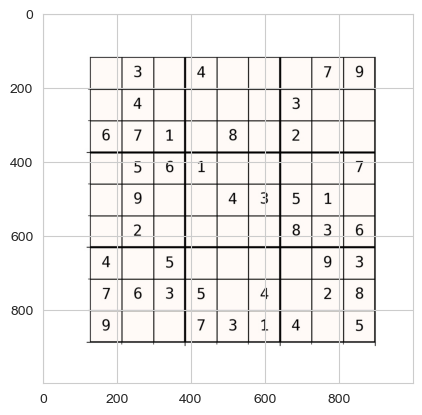

In [261]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

In [262]:
import cv2
import numpy as np

# 二値データに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# 輪郭を見つける
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(largest_contour)

# 各マス目の画像を抽出し、リストに保存
cell_images = []
stepx = w // 9 
stepy = h // 9
trim_size_x = stepx // 7
trim_size_y = stepy // 7
empty_threshold = 100
for i in range(9):
    for j in range(9):
        cell = img[y + i*stepy + trim_size_y : y + (i+1)*stepy - trim_size_y,
               x + j*stepx + trim_size_x : x + (j+1)*stepx - trim_size_x]
        resized_cell = cv2.resize(cell, (28, 28))
        gray_cell = cv2.cvtColor(resized_cell, cv2.COLOR_BGR2GRAY)
        normalized_cell = gray_cell / 255.0
        input_data = normalized_cell.reshape((28, 28, 1))  # モデルの入力形状に合わせてreshapeすること。
        cell_images.append(input_data)

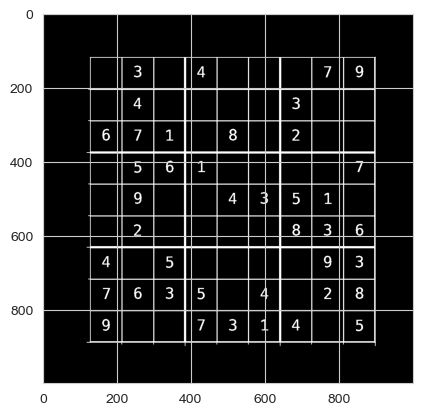

In [263]:
plt.imshow(thresh, cmap="gray")
plt.show()

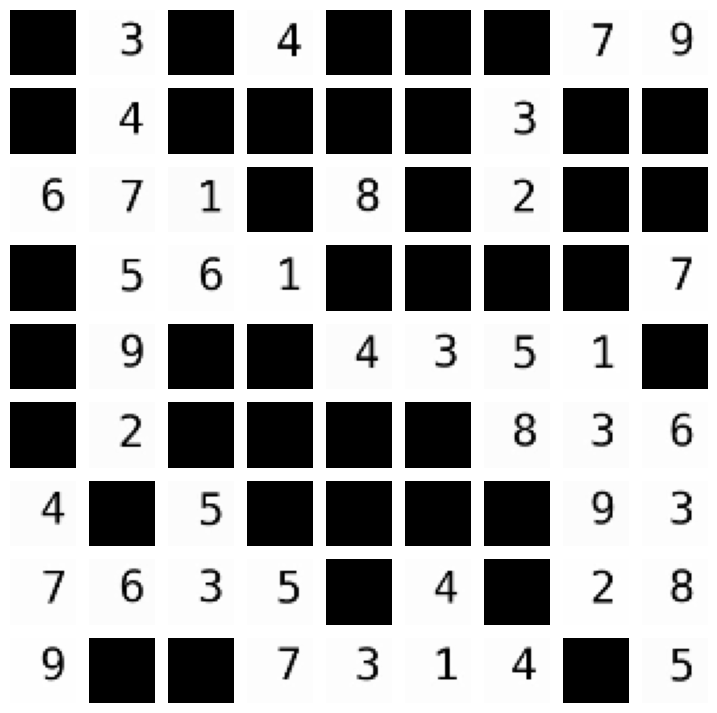

In [264]:
import matplotlib.pyplot as plt

## 抽出結果の可視化

# 9x9のグリッドを作り、各セルに画像をプロット
fig, axs = plt.subplots(9, 9, figsize=(9, 9))
axs = axs.flatten()

# 各軸（ax）について画像をプロット
for ax, cell in zip(axs, cell_images):
    ax.imshow(cell, cmap="gray") # BGRからRGBへ変換
    ax.axis('off')  # 軸の情報をオフにする

plt.show()


## 数字の学習

In [14]:
# データ読み込み
import numpy as np
from sklearn import svm
photos = np.load('../images_and_labels.npz')
x = photos['x']
y = photos['y']
print("len(x)=", len(x))
print(x.shape)
print(y.shape)

# SVMで学習
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=1)
clf = svm.SVC()
clf.fit(X_train, y_train)

len(x)= 20160
(20160, 784)
(20160,)


SVC()

In [330]:
from sklearn import metrics

# 予測の実行
predicted = clf.predict(X_test)
print(f"Classification report for classifier {clf}:\n"
      f"{metrics.classification_report(y_test, predicted)}\n")


Classification report for classifier SVC():
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       596
           1       0.36      0.49      0.42       554
           2       0.48      0.38      0.42       589
           3       0.46      0.47      0.47       562
           4       0.84      0.41      0.55       567
           5       0.57      0.41      0.47       590
           6       0.62      0.46      0.53       592
           7       0.28      0.69      0.40       579
           8       0.51      0.45      0.48       583
           9       0.68      0.42      0.52       584

    accuracy                           0.52      5796
   macro avg       0.58      0.52      0.53      5796
weighted avg       0.58      0.52      0.53      5796


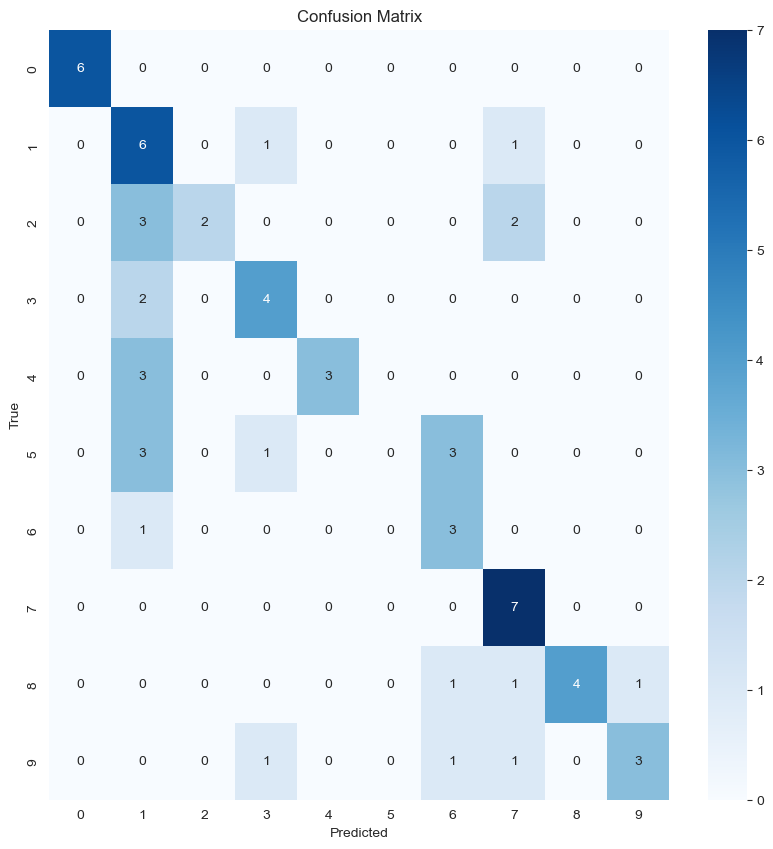

In [316]:
import matplotlib.pyplot as plt
import seaborn as sns

# 混同行列の可視化
conf_mat = metrics.confusion_matrix(y_test, predicted)
plt.figure(figsize=(10, 10))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [254]:
# モデルの保存
import pickle
serials = pickle.dumps(clf)
with open("../rbf_svm.pickle", "wb") as f:
    f.write(serials)

In [255]:
# 再読み込みとテスト
clf2 = None
with open("../rbf_svm.pickle", "rb") as f:
    clf2 = pickle.loads(f.read())

acc_test = clf2.score(X_test, y_test)
print("CV: acc(test)={:.2f}%".format(acc_test))

CV: acc(test)=0.92%


# 数字予測

In [257]:
# [追加] np.arrayに変換してモデル入力用データとする
model_input = np.array(cell_images)

# モデル入力を2次元に変換
model_input_2d = model_input.reshape(model_input.shape[0], -1)
# 予測
predicted = clf.predict(model_input_2d) 


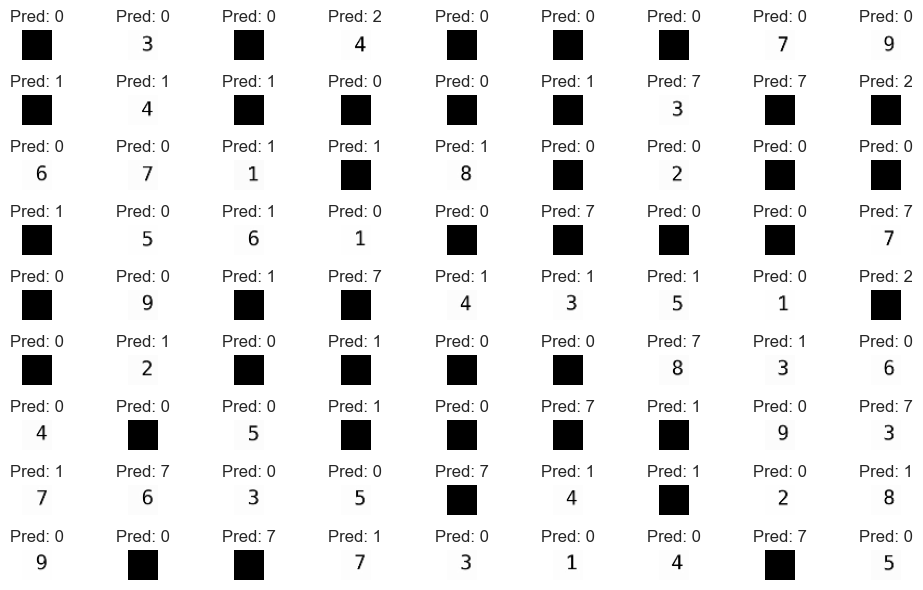

In [265]:
# 画像と予測結果を並べて表示します

# 行と列の数を設定
n_rows = 9
n_cols = 9

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6))

# サブプロットを行と列にわたってループ
for i in range(n_rows):
    for j in range(n_cols):
        idx = i * n_cols + j  # インデックスを計算
        ax = axes[i, j]  # 現在のサブプロットを取得

        # インデックスが画像の数以上になったら終了
        if idx >= len(cell_images):
            break

        ax.imshow(cell_images[idx], cmap='gray')
        ax.set_title(f'Pred: {predicted[idx]}')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [259]:
import numpy as np
textname = filepath + ".txt"
correct_labels = correct_labels = np.loadtxt(textname, dtype=int)
correct_labels_flat = correct_labels.flatten()

# Accuracyを計算して表示
accuracy = metrics.accuracy_score(correct_labels_flat, predicted)
print(f"Accuracy: {accuracy:.2f}")

print(metrics.classification_report(correct_labels_flat, predicted))

Accuracy: 0.52
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        40
           1       0.00      0.00      0.00         4
           2       0.67      0.29      0.40         7
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         6
           5       0.00      0.00      0.00         6
           6       0.00      0.00      0.00         6
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         5
           9       0.00      0.00      0.00         4

    accuracy                           0.52        81
   macro avg       0.16      0.13      0.14        81
weighted avg       0.52      0.52      0.51        81


/Users/yuonoda/anaconda3/envs/advml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/yuonoda/anaconda3/envs/advml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/yuonoda/anaconda3/envs/advml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
